# Branch-wise Analysis and Prediction of Student Placement Using Academic and Skill Factors

---

## Problem Statement

The objective of this study is to predict whether a college student will be placed or not 
while also analyzing placement patterns across different academic branches. By examining 
factors such as CGPA, communication skills, projects, internship experience, and academic 
branch, the study aims to develop a predictive model to estimate placement chances and 
identify branches with higher placement success rates.

---

## Dataset Overview

- **Source:** Raw College Student Placement Dataset
- **Total Records:** 43,500 students
- **Final Clean Records:** ~40,307 students
- **Target Variable:** `Placement` (1 = Placed, 0 = Not Placed)

---

## Process We Used

### Step 1: Data Loading & Initial Inspection
- Loaded raw CSV using `pandas`
- Identified **21 columns** with missing values ranging from **3% to 13%**
- Selected **18 relevant columns** for analysis, dropping unnecessary identifiers

### Step 2: Data Cleaning — Handling Dirty Values
The dataset contained severely corrupted entries beyond simple NaN:

| Column | Issues Found |
|---|---|
| `IQ` | Values like `1e309`, `"one hundred"`, `"5k"`, `999999999` |
| `CGPA` | Values like `"zero.zero"`, `"ten_thousand"`, `"-"` |
| `sem_1` to `sem_8` | Text like `"absent"`, `"fail/pass"`, `"zero.zero"` |
| `Internship_Experience` | Mixed: `"Yes"`, `"y"`, `"YES"`, `"Ye s"`, HTML junk strings |
| `Placement` | Mixed: `"placed"`, `"Placde"`, `"NO"`, `"N"`, empty strings |
| `branch` | Typos like `"Compter Scince"`, `"C.S.E"`, `"cs\|1t"`, HTML garbage |

**Cleaning functions applied:**
- `clean_cgpa()` — removed outliers > 10, converted text to NaN
- `clean_iq()` — clipped to valid range [50, 200], removed junk
- `clean_cgpa_value()` — applied to all 8 semester columns
- `clean__()` — standardized Yes/No → 1/0 for binary columns
- `clean_branch()` — keyword-based mapping to 5 standard branch names

### Step 3: CGPA Reconstruction
- Many students had missing `CGPA` but had semester results available
- Calculated **row-wise mean** across `sem_1` to `sem_8` as `Calculated_Avg`
- Filled missing `CGPA` with this average → created `CGPA_Final`
- Result: CGPA missing rate dropped from **13.2% → 0.23%**

### Step 4: Column Selection
Final working columns selected:
```python

## Imports

Load the core libraries needed for data manipulation, visualisation, and modelling.

In [119]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt 
import seaborn as sns

## Load the dataset

Read the raw CSV file into a pandas DataFrame. All subsequent cleaning steps operate on this object.

In [120]:
df = pd.read_csv('Raw_College_student_placement_dataset.csv')

## Initial missing-value audit

Calculate the percentage of missing values per column so we know the scale of the problem before touching anything.

In [121]:
df.isnull().mean()*100

College_ID                 8.377011
IQ                         9.112644
Prev_Sem_Result           13.085057
CGPA                      13.259770
Academic_Performance       9.850575
Internship_Experience      7.400000
Extra_Curricular_Score    13.466667
Communication_Skills      10.013793
Projects_Completed         9.921839
Placement                  7.340230
college_name               3.531034
sem_1_result               8.921839
sem_2_result               8.988506
sem_3_result               8.894253
sem_4_result               9.029885
sem_5_result               9.135632
sem_6_result               9.101149
sem_7_result               8.770115
sem_8_result               8.268966
branch                     8.965517
KT                         6.326437
dtype: float64

## Inspect dirty values in a sample column

Print the value counts for `sem_1_result` to get a feel for the kinds of junk that appear across the semester columns.

In [122]:
df['sem_1_result'].value_counts()

sem_1_result
detained        1042
absent          1034
withheld         963
-                883
?                848
                ... 
5.88;-999999       1
6.42;5k            1
7.74;-inf          1
6.17;1e309         1
8.52;-inf          1
Name: count, Length: 2999, dtype: int64

## Inspect column names

Confirm exactly which columns the raw dataset contains before deciding which ones to keep.

In [123]:
df.columns

Index(['College_ID', 'IQ', 'Prev_Sem_Result', 'CGPA', 'Academic_Performance',
       'Internship_Experience', 'Extra_Curricular_Score',
       'Communication_Skills', 'Projects_Completed', 'Placement',
       'college_name', 'sem_1_result', 'sem_2_result', 'sem_3_result',
       'sem_4_result', 'sem_5_result', 'sem_6_result', 'sem_7_result',
       'sem_8_result', 'branch', 'KT'],
      dtype='object')

## Select the working columns

Define the subset of columns relevant to the analysis and drop everything else (e.g., `College_ID`, `college_name`).

In [124]:
modify = [ 'IQ',  'CGPA', 'Academic_Performance',
        'Internship_Experience', 'Extra_Curricular_Score',
        'Communication_Skills', 'Projects_Completed', 'Placement',
            'branch', 'KT','sem_1_result', 'sem_2_result', 'sem_3_result',
       'sem_4_result', 'sem_5_result', 'sem_6_result', 'sem_7_result',
       'sem_8_result']


In [125]:
df = df[modify]

## Missing-value audit after column selection

Recheck the null percentages on the reduced DataFrame to confirm nothing changed unexpectedly.

In [126]:
df.isnull().mean()*100

IQ                         9.112644
CGPA                      13.259770
Academic_Performance       9.850575
Internship_Experience      7.400000
Extra_Curricular_Score    13.466667
Communication_Skills      10.013793
Projects_Completed         9.921839
Placement                  7.340230
branch                     8.965517
KT                         6.326437
sem_1_result               8.921839
sem_2_result               8.988506
sem_3_result               8.894253
sem_4_result               9.029885
sem_5_result               9.135632
sem_6_result               9.101149
sem_7_result               8.770115
sem_8_result               8.268966
dtype: float64

## Inspect IQ column

Print the full IQ series to spot obvious junk values before writing the cleaning function.

In [127]:
df['IQ']

0              1e309
1                120
2                117
3                127
4              1e309
            ...     
43495             81
43496           115 
43497    one hundred
43498           5.82
43499             73
Name: IQ, Length: 43500, dtype: object

## Drop rows with missing `Placement`

`Placement` is our target variable. Rows where it is missing cannot be used for training or evaluation, so we drop them immediately.

In [128]:
df.dropna(subset=['Placement'], inplace=True)

## Missing-value audit after dropping null `Placement` rows

In [129]:
df.isnull().mean()*100

IQ                         9.127447
CGPA                      13.084576
Academic_Performance       9.817153
Internship_Experience      7.385814
Extra_Curricular_Score    13.439353
Communication_Skills       9.958568
Projects_Completed         9.881658
Placement                  0.000000
branch                     8.926489
KT                         6.331406
sem_1_result               8.904161
sem_2_result               8.981070
sem_3_result               8.896718
sem_4_result               9.048056
sem_5_result               9.172104
sem_6_result               9.107599
sem_7_result               8.762746
sem_8_result               8.209492
dtype: float64

## Clean continuous / score columns

Define `clean_cgpa()` — a general-purpose cleaner for CGPA, score, and count columns — and apply it to each relevant column.

It converts text to `NaN`, removes nonsense values (`1e309`, `5k`, etc.), and clips the valid range to **[0, 10]**.

In [130]:


def clean_cgpa(value):
    val = str(value).strip().lower()
    
    text_junk = ['zero.zero', 'ten_thousand', '?', 'nan', 'none', '']
    if val in text_junk:
        return np.nan
    if val.endswith('k'):
        return np.nan
    

    try:
        num = float(val)
    except ValueError:
        return np.nan
    
    if abs(num) > 10 or num < 0:
        return np.nan
    
    return num



df['CGPA'] = df['CGPA'].apply(clean_cgpa)
df['Extra_Curricular_Score'] = df['Extra_Curricular_Score'].apply(clean_cgpa)
df['Communication_Skills'] = df['Communication_Skills'].apply(clean_cgpa)
df['Academic_Performance'] = df['Academic_Performance'].apply(clean_cgpa)
df['Projects_Completed'] = df['Projects_Completed'].apply(clean_cgpa)
df['KT'] = df['KT'].apply(clean_cgpa)




## Verify CGPA cleaning

Print the first five cleaned CGPA values to confirm the function worked.

In [131]:
df['CGPA'].head(5)

0     NaN
1    1.66
2     NaN
3     NaN
4    5.57
Name: CGPA, dtype: float64

## Clean semester columns

Define `clean_cgpa_value()` — a variant that also maps known text typos to numbers — and apply it to all eight semester result columns.

In [132]:
import pandas as pd
import numpy as np


sem_cols = ['sem_1_result', 'sem_2_result', 'sem_3_result',
       'sem_4_result', 'sem_5_result', 'sem_6_result', 'sem_7_result',
       'sem_8_result']

def clean_cgpa_value(val):

    val = str(val).lower().strip()
    mapping = {'zero.zero': 0.0, '5k': 5.0, 'ten_thousand': 10.0, '?': np.nan}
    if val in mapping:
        return mapping[val]

    try:
        num = float(val)
        return num if 0 <= num <= 10 else np.nan
    except:
        return np.nan


for col in sem_cols:
    df[col] = df[col].apply(clean_cgpa_value)

## Preview the DataFrame after cleaning

In [133]:
df

,IQ,CGPA,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,Placement,branch,KT,sem_1_result,sem_2_result,sem_3_result,sem_4_result,sem_5_result,sem_6_result,sem_7_result,sem_8_result
0,1e309,NaN,NaN,y,NaN,NaN,NaN,placed,eec/mech,2.0,NaN,7.21,NaN,5.0,7.19,9.48,6.63,4.41
1,120,1.66,NaN,No,NaN,2.0,NaN,Placde,cse,3.0,0.00,NaN,4.49,NaN,NaN,NaN,5.80,0.00
2,117,NaN,3.0,Ye s,6.0,7.0,NaN,,IT,NaN,NaN,8.07,NaN,NaN,NaN,NaN,5.20,NaN
3,127,NaN,5.0,Ye s,4.0,NaN,NaN,NO,Civil,NaN,5.05,NaN,6.59,NaN,NaN,7.25,NaN,8.55
4,1e309,5.57,8.0,Yes,1.0,NaN,2.0,NO,C.S.E,3.0,NaN,NaN,8.39,NaN,8.88,NaN,5.65,4.95
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
43495,81,NaN,NaN,No,3.0,NaN,0.0,N,AIML,NaN,NaN,4.79,NaN,NaN,9.64,NaN,7.37,7.67
43496,115,8.56,NaN,y,3.0,NaN,NaN,Yes,C.S.E,2.0,NaN,6.82,NaN,0.0,NaN,6.13,8.74,NaN
43497,one hundred,NaN,8.0,n,1.0,NaN,NaN,Yes,cs|1t,3.0,7.31,9.38,NaN,NaN,6.26,8.66,NaN,NaN
43498,5.82,NaN,NaN,no,NaN,NaN,NaN,YES,CSE,NaN,9.67,6.74,6.41,NaN,NaN,NaN,NaN,NaN


## Reconstruct `CGPA_Final`

Many students have a missing CGPA but valid semester results. We fill the gap by taking the row-wise mean across `sem_1_result`–`sem_8_result` and storing the result in a new column `CGPA_Final`.

In [134]:
df['Calculated_Avg'] = df[sem_cols].mean(axis=1)

df['CGPA_Final'] = df['CGPA'].fillna(df['Calculated_Avg'])

## Confirm new column exists

In [135]:
df.columns

Index(['IQ', 'CGPA', 'Academic_Performance', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed',
       'Placement', 'branch', 'KT', 'sem_1_result', 'sem_2_result',
       'sem_3_result', 'sem_4_result', 'sem_5_result', 'sem_6_result',
       'sem_7_result', 'sem_8_result', 'Calculated_Avg', 'CGPA_Final'],
      dtype='object')

## Narrow down to the final modelling columns

Drop the eight semester columns and `CGPA` now that `CGPA_Final` has been created.

In [136]:
modify1 = ['IQ', 'Academic_Performance', 'Internship_Experience',
        'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed',
        'branch', 'KT',  'CGPA_Final',
        'Placement'] 

In [137]:
df = df[modify1]

## Inspect IQ dirty values

List the most frequent IQ values to understand what garbage patterns need to be handled.

In [138]:
df['IQ'].value_counts()

IQ
5k               2155
999999999        1138
1e309            1127
-1e308           1124
ten_thousand     1107
                 ... 
vit vellore         1
C.S.E               1
 4.92               1
iit hyderabad       1
4.93                1
Name: count, Length: 662, dtype: int64

## Preview first three rows

In [139]:
df.head(3)

,IQ,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,branch,KT,CGPA_Final,Placement
0,1e309,NaN,y,NaN,NaN,NaN,eec/mech,2.0,6.653333,placed
1,120,NaN,No,NaN,2.0,NaN,cse,3.0,1.660000,Placde
2,117,3.0,Ye s,6.0,7.0,NaN,IT,NaN,6.635000,


## Clean the IQ column

Define `clean_iq()` to convert text to `NaN`, catch scientific-notation outliers, and clip to the physiologically valid range **[50, 200]**.

In [140]:

def clean_iq(value):
    val = str(value).strip().lower()
    

    text_junk = ['zero.zero', 'ten_thousand', '?', 'nan', 'none', '', 'yes']
    if val in text_junk or 'k' in val:
        return np.nan
    
    try:
        num = float(val)
    except ValueError:
        return np.nan
    
    if num < 50 or num > 200: 
        return np.nan
    
    return num


df['IQ'] = df['IQ'].apply(clean_iq)



C:\Users\Admin\AppData\Local\Temp\ipykernel_16016\2257921866.py:20: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['IQ'] = df['IQ'].apply(clean_iq)


## Preview last ten rows

In [141]:
df.tail(10)

,IQ,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,branch,KT,CGPA_Final,Placement
43489,NaN,NaN,No,8.0,5.0,NaN,Electronics,NaN,6.260000,No
43490,100.0,3.0,no,NaN,NaN,5.0,Mechanical,NaN,7.530000,No
43491,NaN,NaN,YES,NaN,NaN,NaN,cee/mech,NaN,8.840000,n
43493,NaN,NaN,No,NaN,5.0,NaN,c|sit,NaN,6.855000,No
43494,NaN,NaN,no,3.0,NaN,NaN,Computer Science,1.0,6.186000,Yes
43495,81.0,NaN,No,3.0,NaN,0.0,AIML,NaN,7.367500,N
43496,115.0,NaN,y,3.0,NaN,NaN,C.S.E,2.0,8.560000,Yes
43497,NaN,8.0,n,1.0,NaN,NaN,cs|1t,3.0,7.902500,Yes
43498,NaN,NaN,no,NaN,NaN,NaN,CSE,NaN,7.606667,YES
43499,73.0,1.0,Yes,3.0,1.0,NaN,MECH,NaN,6.470000,No


## Inspect `Internship_Experience` dirty values

List value counts to see the mix of `'Yes'`/`'y'`/`'YES'`/`'Ye s'` and HTML junk strings.

In [142]:
df['Internship_Experience'].value_counts()

Internship_Experience
No                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                

## Standardise binary columns

Define `clean__()` to map all yes-like strings → `1`, all no-like strings → `0`, and anything else → `NaN`. Apply to both `Internship_Experience` and `Placement`.

In [143]:

def clean__(value):

    val = str(value).strip().lower()
    

    if val.startswith('y') or 'yes' in val:
        return 1
    

    if val.startswith('n') or 'no' in val or val == '0':
        return 0
    if val.startswith('p') or 'yes' in val:
        return 1
    return np.nan


df['Internship_Experience'] = df['Internship_Experience'].apply(clean__)
df['Placement'] = df['Placement'].apply(clean__)



C:\Users\Admin\AppData\Local\Temp\ipykernel_16016\1072539128.py:17: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Internship_Experience'] = df['Internship_Experience'].apply(clean__)
C:\Users\Admin\AppData\Local\Temp\ipykernel_16016\1072539128.py:18: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Placement'] = df['Placement'].apply(clean__)


## Preview the DataFrame after binary cleaning

In [144]:
df

,IQ,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,branch,KT,CGPA_Final,Placement
0,NaN,NaN,1.0,NaN,NaN,NaN,eec/mech,2.0,6.653333,1.0
1,120.0,NaN,0.0,NaN,2.0,NaN,cse,3.0,1.660000,1.0
2,117.0,3.0,1.0,6.0,7.0,NaN,IT,NaN,6.635000,NaN
3,127.0,5.0,1.0,4.0,NaN,NaN,Civil,NaN,6.860000,0.0
4,NaN,8.0,1.0,1.0,NaN,2.0,C.S.E,3.0,5.570000,0.0
...,...,...,...,...,...,...,...,...,...,...
43495,81.0,NaN,0.0,3.0,NaN,0.0,AIML,NaN,7.367500,0.0
43496,115.0,NaN,1.0,3.0,NaN,NaN,C.S.E,2.0,8.560000,1.0
43497,NaN,8.0,0.0,1.0,NaN,NaN,cs|1t,3.0,7.902500,1.0
43498,NaN,NaN,0.0,NaN,NaN,NaN,CSE,NaN,7.606667,1.0


## Missing-value audit after binary cleaning

In [145]:
df.isnull().mean()*100

IQ                        62.410996
Academic_Performance      55.709926
Internship_Experience      8.911603
Extra_Curricular_Score    54.538914
Communication_Skills      54.987967
Projects_Completed        56.982658
branch                     8.926489
KT                        43.027266
CGPA_Final                 0.233210
Placement                  9.745206
dtype: float64

## Inspect `branch` dirty values

List value counts to see the full range of branch-name variations and junk.

In [146]:
df['branch'].value_counts()

branch
CSE                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                              

## Standardise `branch` labels

Define `clean_branch()` to map every variant to one of five canonical names (`Computer Science`, `Mechanical Engineering`, `Electronics Engineering`, `Information Technology`, `Civil Engineering`) via keyword matching. Everything else becomes `NaN`.

In [147]:

def clean_branch(value):

    val = str(value).strip().lower()
    

    if 'cs' in val or 'computer' in val:
        return 'Computer Science'
    
    if 'civil' in val:
        return 'Civil Engineering'
    
    if 'mech' in val:
        return 'Mechanical Engineering'
    
    if 'elect' in val or 'ece' in val or 'eee' in val:
        return 'Electronics Engineering'
    
    if 'it' in val and 'cs' not in val:
        return 'Information Technology'


    return np.nan


df['branch'] = df['branch'].apply(clean_branch)



C:\Users\Admin\AppData\Local\Temp\ipykernel_16016\771132040.py:25: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['branch'] = df['branch'].apply(clean_branch)


## Preview the DataFrame after branch cleaning

In [148]:
df

,IQ,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,branch,KT,CGPA_Final,Placement
0,NaN,NaN,1.0,NaN,NaN,NaN,Mechanical Engineering,2.0,6.653333,1.0
1,120.0,NaN,0.0,NaN,2.0,NaN,Computer Science,3.0,1.660000,1.0
2,117.0,3.0,1.0,6.0,7.0,NaN,Information Technology,NaN,6.635000,NaN
3,127.0,5.0,1.0,4.0,NaN,NaN,Civil Engineering,NaN,6.860000,0.0
4,NaN,8.0,1.0,1.0,NaN,2.0,NaN,3.0,5.570000,0.0
...,...,...,...,...,...,...,...,...,...,...
43495,81.0,NaN,0.0,3.0,NaN,0.0,NaN,NaN,7.367500,0.0
43496,115.0,NaN,1.0,3.0,NaN,NaN,NaN,2.0,8.560000,1.0
43497,NaN,8.0,0.0,1.0,NaN,NaN,Computer Science,3.0,7.902500,1.0
43498,NaN,NaN,0.0,NaN,NaN,NaN,Computer Science,NaN,7.606667,1.0


# MICE Imputation (Multiple Imputation by Chained Equations)

MICE is a robust technique for handling missing data. Instead of filling every missing value with a single global statistic (mean/median), MICE treats each incomplete column as a **regression target** and predicts its missing values using all other columns. It repeats this process iteratively across all columns until the imputations converge.

---

## Why MICE?

| Method | Problem |
|---|---|
| Mean/median fill | Distorts variance, ignores relationships between features |
| Drop rows | Loses data, biased if missing is not random |
| MICE | Preserves multivariate relationships, works for mixed data types |

---

## How It Works (Conceptually)

For each column `X_j` with missing values:

1. Temporarily fill `X_j` with its column mean
2. Train a model: `X_j ~ X_1 + X_2 + ... + X_{j-1} + X_{j+1} + ...` (all other columns as features)
3. Use the model to predict and fill the missing entries in `X_j`
4. Move to the next column and repeat
5. Do this for **max_iter** full cycles — each cycle refines the previous one

```
Iteration 1:  col_A → col_B → col_C → col_D  (rough initial fills)
Iteration 2:  col_A → col_B → col_C → col_D  (improved, uses better fills from iter 1)
...
Iteration N:  converged stable imputations
```

---

## Step 0 — Imports

In [149]:
from sklearn.experimental import enable_iterative_imputer  # must import before IterativeImputer
from sklearn.impute import IterativeImputer
from sklearn.preprocessing import LabelEncoder

---

## Step 1 — Reset Index

Always reset the index before imputation. Non-sequential indices cause silent misalignment when writing imputed values back.

In [150]:
df = df.reset_index(drop=True)

---

## Step 2 — Encode Categorical Columns

`IterativeImputer` only accepts **numeric arrays**. Any categorical column must be integer-encoded before imputation, then decoded afterward.

> **Key detail:** Fit the encoder only on *known* (non-null) values. Set unknown values to `NaN` — not to a dummy integer — so the imputer treats them correctly.

In [151]:
branch_encoder = LabelEncoder()
known_mask = df['branch'].notna()

branch_encoder.fit(df.loc[known_mask, 'branch'])


df['branch_encoded'] = np.nan
df.loc[known_mask, 'branch_encoded'] = branch_encoder.transform(
    df.loc[known_mask, 'branch']
).astype(float)

print("Encoded classes:", branch_encoder.classes_)
print(df[['branch', 'branch_encoded']].head())

Encoded classes: ['Civil Engineering' 'Computer Science' 'Electronics Engineering'
 'Information Technology' 'Mechanical Engineering']
                   branch  branch_encoded
0  Mechanical Engineering             4.0
1        Computer Science             1.0
2  Information Technology             3.0
3       Civil Engineering             0.0
4                     NaN             NaN


---

## Step 3 — Select Columns to Impute

Include **all** numeric columns that have missing values (or that help predict the missing ones). More informative columns → better imputation.

In [152]:
impute_cols = [
    'IQ',
    'CGPA_Final',
    'Academic_Performance',
    'Internship_Experience',   
    'Extra_Curricular_Score',
    'Communication_Skills',
    'Projects_Completed',      
    'KT',                      
    'branch_encoded', 
    'Placement']       

impute_df = df[impute_cols].copy()

print("Missing values before imputation:")
print(impute_df.isnull().sum())

Missing values before imputation:
IQ                        25156
CGPA_Final                   94
Academic_Performance      22455
Internship_Experience      3592
Extra_Curricular_Score    21983
Communication_Skills      22164
Projects_Completed        22968
KT                        17343
branch_encoded            17988
Placement                  3928
dtype: int64


---

## Step 4 — Fit and Transform with IterativeImputer

### Key parameters

| Parameter | Value used | What it does |
|---|---|---|
| `estimator` | `BayesianRidge` (default) | Regression model used per column; fast and robust |
| `max_iter` | `10` | Number of full chained-equation cycles |
| `min_value` | `0` | Clamps all outputs ≥ 0 (no negative scores/counts) |
| `random_state` | `42` | Reproducibility |
| `verbose` | `1` | Prints convergence info per iteration |

> For purely continuous features, `BayesianRidge` is usually the best default.  
> For heavily categorical or non-linear data, swap in `RandomForestRegressor`.

In [153]:
mice_imputer = IterativeImputer(
    max_iter=10,
    random_state=42,
    min_value=0,
    verbose=1
)

imputed_array = mice_imputer.fit_transform(impute_df)
imputed_df = pd.DataFrame(imputed_array, columns=impute_cols)

[IterativeImputer] Completing matrix with shape (40307, 10)
[IterativeImputer] Change: 6.157465784935586, scaled tolerance: 0.2 
[IterativeImputer] Change: 10.634119127170322, scaled tolerance: 0.2 
[IterativeImputer] Change: 34.1379342119856, scaled tolerance: 0.2 
[IterativeImputer] Change: 26.88464271897607, scaled tolerance: 0.2 
[IterativeImputer] Change: 15.256234962805628, scaled tolerance: 0.2 
[IterativeImputer] Change: 12.774007896611408, scaled tolerance: 0.2 
[IterativeImputer] Change: 7.282719994816583, scaled tolerance: 0.2 
[IterativeImputer] Change: 4.023518689163055, scaled tolerance: 0.2 
[IterativeImputer] Change: 2.890563001450843, scaled tolerance: 0.2 
[IterativeImputer] Change: 2.672228592961851, scaled tolerance: 0.2 


c:\Users\Admin\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:867: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


---

## Step 5 — Post-process Imputed Values

MICE returns **raw floats for every column**, regardless of the original dtype. You must enforce domain constraints manually:

- **Binary columns** → round to 0 or 1
- **Count/integer columns** → round to nearest integer
- **Bounded continuous columns** → clip to valid range

In [154]:
imputed_df['Internship_Experience'] = imputed_df['Internship_Experience'].round().astype(int)
imputed_df['Placement']  = imputed_df['Placement'].round().astype(int)


imputed_df['KT']   = imputed_df['KT'].round().astype(int)
imputed_df['Projects_Completed'] = imputed_df['Projects_Completed'].round().astype(int)


imputed_df['IQ'] = imputed_df['IQ'].clip(50, 200).round().astype(int)


for col in ['Academic_Performance', 'Extra_Curricular_Score', 'Communication_Skills', 'CGPA_Final']:
    imputed_df[col] = imputed_df[col].clip(0, 10)


n_classes = len(branch_encoder.classes_)
imputed_df['branch_encoded'] = (
    imputed_df['branch_encoded']
    .round()
    .clip(0, n_classes - 1)
    .astype(int)
)
imputed_df['branch'] = branch_encoder.inverse_transform(imputed_df['branch_encoded'])

---

## Step 6 — Write Back to DataFrame

In [155]:
for col in impute_cols:
    df[col] = imputed_df[col].values

df['branch'] = imputed_df['branch'].values

df.drop(columns=['branch_encoded'], inplace=True)

---

## Step 7 — Verify

In [156]:
print("=== Null counts after MICE ===")
print(df.isnull().sum())
print(f"\nShape: {df.shape}")
df.head()

=== Null counts after MICE ===
IQ                        0
Academic_Performance      0
Internship_Experience     0
Extra_Curricular_Score    0
Communication_Skills      0
Projects_Completed        0
branch                    0
KT                        0
CGPA_Final                0
Placement                 0
dtype: int64

Shape: (40307, 10)


,IQ,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,branch,KT,CGPA_Final,Placement
0,100,5.814012,1,6.154023,4.842362,2,Mechanical Engineering,2,6.653333,1
1,120,3.712947,0,3.593549,2.000000,3,Computer Science,3,1.660000,1
2,117,3.000000,1,6.000000,7.000000,0,Information Technology,6,6.635000,1
3,127,5.000000,1,4.000000,3.057480,2,Civil Engineering,3,6.860000,0
4,102,8.000000,1,1.000000,5.335326,2,Electronics Engineering,3,5.570000,0


---

## Summary

```
raw df  →  reset_index  →  encode categoricals  →  IterativeImputer.fit_transform
       →  post-process (round / clip)  →  decode categoricals  →  write back
```

**When to adjust:**
- Increase `max_iter` (e.g. 20–50) if convergence warnings appear
- Swap `BayesianRidge` for `RandomForestRegressor` if the data is highly non-linear
- Add `sample_posterior=True` for true multiple imputation (creates stochastic draws instead of point estimates)

## Final DataFrame preview

Confirm all imputed values look reasonable before moving to the next steps.

In [157]:
df

,IQ,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,branch,KT,CGPA_Final,Placement
0,100,5.814012,1,6.154023,4.842362,2,Mechanical Engineering,2,6.653333,1
1,120,3.712947,0,3.593549,2.000000,3,Computer Science,3,1.660000,1
2,117,3.000000,1,6.000000,7.000000,0,Information Technology,6,6.635000,1
3,127,5.000000,1,4.000000,3.057480,2,Civil Engineering,3,6.860000,0
4,102,8.000000,1,1.000000,5.335326,2,Electronics Engineering,3,5.570000,0
...,...,...,...,...,...,...,...,...,...,...
40302,81,2.562965,0,3.000000,6.993864,0,Electronics Engineering,2,7.367500,0
40303,115,6.565292,1,3.000000,4.374389,2,Computer Science,2,8.560000,1
40304,105,8.000000,0,1.000000,6.182649,3,Computer Science,3,7.902500,1
40305,104,5.286096,0,4.685734,6.195628,3,Computer Science,3,7.606667,1


## Post-imputation distribution plots

Histograms for the six key numeric columns — verify that distributions look plausible and no out-of-range values remain after MICE.

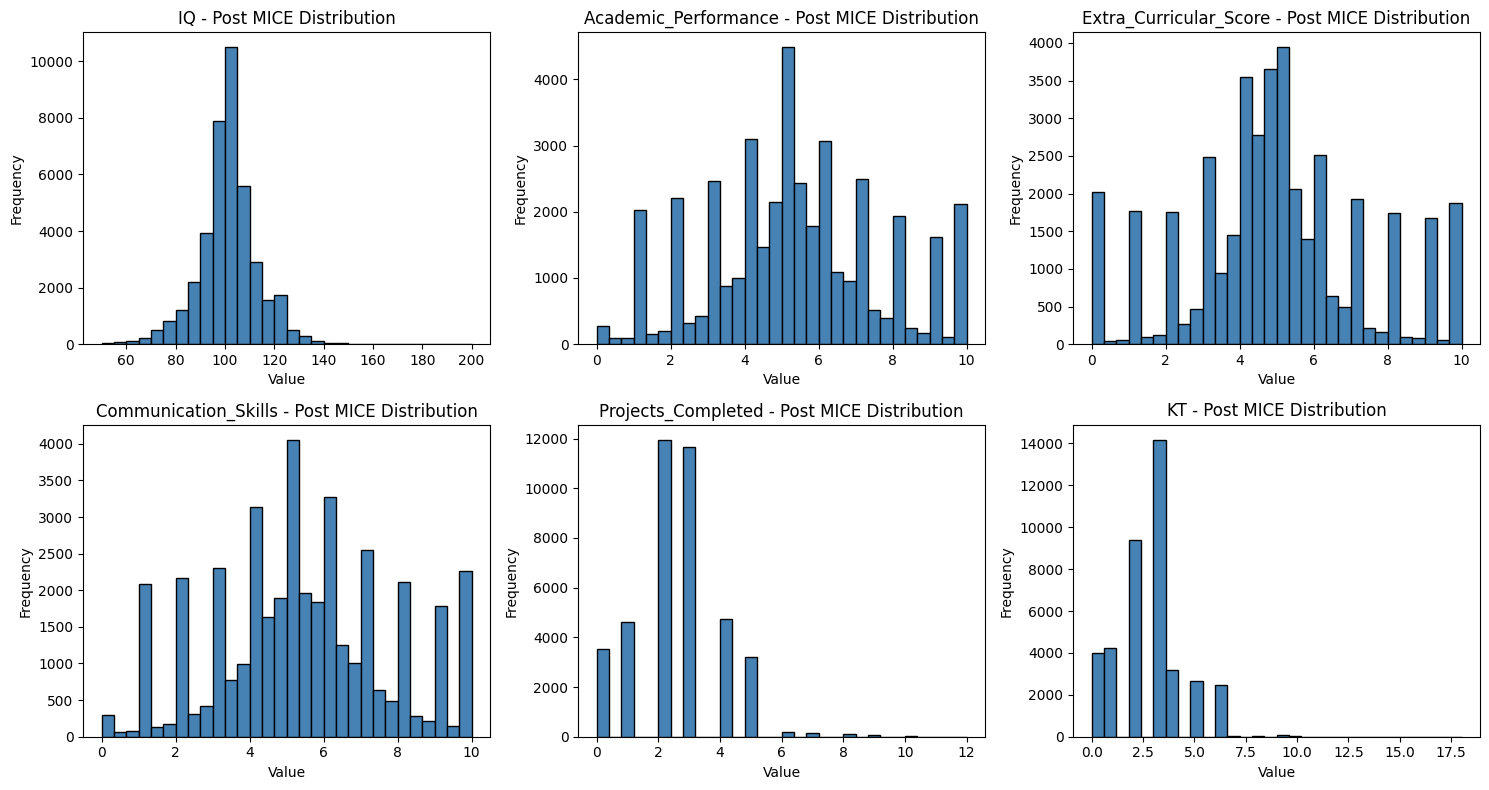

In [158]:

import matplotlib.pyplot as plt

cols_to_check = ['IQ', 'Academic_Performance', 'Extra_Curricular_Score', 
                 'Communication_Skills', 'Projects_Completed', 'KT']

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for i, col in enumerate(cols_to_check):
    axes[i].hist(df[col], bins=30, color='steelblue', edgecolor='black')
    axes[i].set_title(f'{col} - Post MICE Distribution')
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

## Encode `branch` for modelling

Now that MICE has filled all missing branch values, re-encode the column with `LabelEncoder` to produce a numeric `branch_encoded` column ready for downstream models.

In [159]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
df['branch_encoded'] = le.fit_transform(df['branch'].fillna('Unknown'))


mapping = dict(zip(le.classes_, le.transform(le.classes_)))
print("Branch Encoding Mapping:")
for branch, code in mapping.items():
    print(f"  {branch} --> {code}")

Branch Encoding Mapping:
  Civil Engineering --> 0
  Computer Science --> 1
  Electronics Engineering --> 2
  Information Technology --> 3
  Mechanical Engineering --> 4


## Confirm columns after encoding

In [160]:
df.columns

Index(['IQ', 'Academic_Performance', 'Internship_Experience',
       'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed',
       'branch', 'KT', 'CGPA_Final', 'Placement', 'branch_encoded'],
      dtype='object')

## Final column selection

Drop the original `branch` string column, keeping only the numeric `branch_encoded`.

In [161]:
modify2 = ['IQ', 'Academic_Performance', 'Internship_Experience',
        'Extra_Curricular_Score', 'Communication_Skills', 'Projects_Completed', 'branch_encoded', 'KT', 'CGPA_Final', 'Placement']

In [162]:
df = df[modify2]

## Preview the final, model-ready DataFrame

In [163]:
df

,IQ,Academic_Performance,Internship_Experience,Extra_Curricular_Score,Communication_Skills,Projects_Completed,branch_encoded,KT,CGPA_Final,Placement
0,100,5.814012,1,6.154023,4.842362,2,4,2,6.653333,1
1,120,3.712947,0,3.593549,2.000000,3,1,3,1.660000,1
2,117,3.000000,1,6.000000,7.000000,0,3,6,6.635000,1
3,127,5.000000,1,4.000000,3.057480,2,0,3,6.860000,0
4,102,8.000000,1,1.000000,5.335326,2,2,3,5.570000,0
...,...,...,...,...,...,...,...,...,...,...
40302,81,2.562965,0,3.000000,6.993864,0,2,2,7.367500,0
40303,115,6.565292,1,3.000000,4.374389,2,1,2,8.560000,1
40304,105,8.000000,0,1.000000,6.182649,3,1,3,7.902500,1
40305,104,5.286096,0,4.685734,6.195628,3,1,3,7.606667,1


## Export to CSV

Save the cleaned and imputed DataFrame as `cleaned_placement_data.csv` for use in subsequent modelling notebooks.

In [164]:
df.to_csv('cleaned_placement_data.csv', index=False)

print(" File exported successfully :)")
print(f"Shape: {df.shape}")


 File exported successfully :)
Shape: (40307, 10)
